# Evaluacion Modelo 9 (Mejor Modelo)

In [ ]:
%cd ..

/


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,accuracy_score
import os
from tensorflow.keras.applications.densenet import preprocess_input

In [ ]:
import random
import tensorflow as tf
import os


## Carga de Datos

In [ ]:
from src.carga import cargar_datos

In [ ]:
root = 'data/Garbage-classification/Garbage-classification/'
df = cargar_datos(root)
df.head()

,x,y
1134,data/Garbage-classification/Garbage-classifica...,metal
2487,data/Garbage-classification/Garbage-classifica...,trash
2228,data/Garbage-classification/Garbage-classifica...,plastic
2346,data/Garbage-classification/Garbage-classifica...,plastic
2048,data/Garbage-classification/Garbage-classifica...,plastic


## Carga de datos en Colab

In [ ]:
import kagglehub

# Descargar dataset
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print(f"📦 Dataset descargado en: {path}")

Using Colab cache for faster access to the 'garbage-classification' dataset.
📦 Dataset descargado en: /kaggle/input/garbage-classification


In [ ]:
import pandas as pd
import os

def cargar_datos_colab(ruta_archivo):
    data = {}

    for i in os.listdir(ruta_archivo):
      if i == 'Garbage classification':
        ruta_clase = os.path.join(ruta_archivo,i)
        if os.path.isdir(ruta_clase):
            for ruta_actual, subcarpetas, archivos in os.walk(ruta_clase):
                for k in archivos:
                    data[os.path.join(ruta_actual, k)] = os.path.basename(ruta_actual)

    df = pd.DataFrame(data.items(), columns=['x', 'y'])
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

In [ ]:
df = cargar_datos_colab(path)

## Division de los datos

In [ ]:
from sklearn.model_selection import train_test_split

# 80% train, 20% (test + validación)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['y']
 )

# Del 20% (test + validacion): 10% validación y 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['y']
 )

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validación: {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test: {len(test_df)} ({len(test_df)/len(df):.1%})")

Train: 2021 (80.0%)
Validación: 253 (10.0%)
Test: 253 (10.0%)


## Modificacion de las imagenes y carga en memoria.

In [ ]:
def load_images(df, size):
    images = []
    labels = []

    for _, row in df.iterrows():
        ruta = row['x']
        label = row['y']

        img = cv2.imread(ruta)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size, size))
        #img = img.astype('float32') / 255.0

        images.append(img)
        labels.append(label)

    X = np.array(images)
    y = np.array(labels)

    return X, y

In [ ]:
x_train, y_train = load_images(train_df, size=128)
x_val, y_val = load_images(val_df, size=128)
x_test, y_test = load_images(test_df, size=128)

In [ ]:

x_train = preprocess_input(x_train.astype("float32"))
x_val = preprocess_input(x_val.astype("float32"))
x_test = preprocess_input(x_test.astype("float32"))

In [ ]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((2021, 128, 128, 3),
 (2021,),
 (253, 128, 128, 3),
 (253,),
 (253, 128, 128, 3),
 (253,))

Encoder para los labels

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val  = le.transform(y_val)
y_test  = le.transform(y_test)

In [ ]:
le.classes_

array(['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'],
      dtype='<U9')

## Aplicacion del modelo

In [ ]:
from modelo9 import estructura_modelo
from modelo_simple import compilar
from curvas import graf_pedida,graf_acc,plot_confusion
from semillas import aplicar_semilla

## Bucle para probar rendimiento modelo con diferentes semillas

In [ ]:
# Ejecuta esta celda solo en Colab para persistir resultados en Google Drive
if "google.colab" in str(get_ipython()):
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Entrenando modelo con semilla: 42


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,349,574 (28.04 MB)

 Trainable params: 7,265,926 (27.72 MB)

 Non-trainable params: 83,648 (326.75 KB)

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 318s 10s/step - loss: 2.3005 - sparse_categorical_accuracy: 0.1737 - val_loss: 1.5385 - val_sparse_categorical_accuracy: 0.4269 - learning_rate: 1.0000e-04
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 380ms/step - loss: 1.7584 - sparse_categorical_accuracy: 0.3083 - val_loss: 1.3057 - val_sparse_categorical_accuracy: 0.6126 - learning_rate: 1.0000e-04
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 374ms/step - loss: 1.5060 - sparse_categorical_accuracy: 0.3914 - val_loss: 1.1315 - val_sparse_categorical_accuracy: 0.6838 - learning_rate: 1.0000e-04
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 379ms/step - loss: 1.3202 - sparse_categorical_accuracy: 0.4894 - val_loss: 0.9816 - val_sparse_categorical_accuracy: 0.6877 - learning_rate: 1.0000e-04
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 386ms/step - loss: 1.1535 - sparse_categorical_accuracy: 0.5567 - val_loss: 0.8366 - val_sparse_categorical_accuracy: 0.7115 - learning_rate: 1.0000e-04
Epoch 6/150
16/16 ━━━━━━━

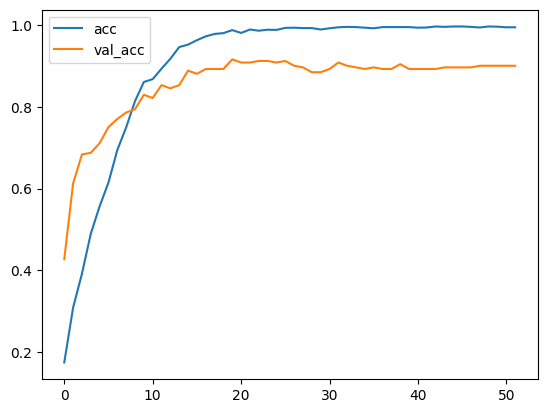

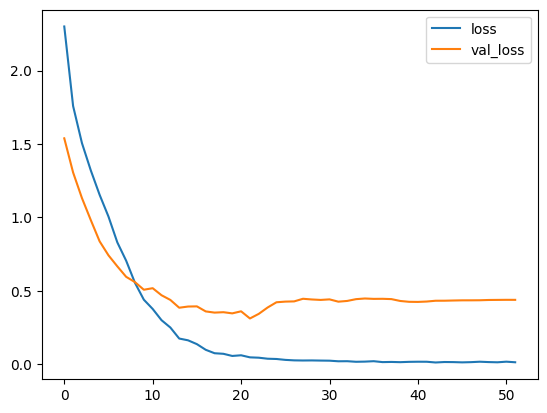

Entrenando modelo con semilla: 123


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,349,574 (28.04 MB)

 Trainable params: 7,265,926 (27.72 MB)

 Non-trainable params: 83,648 (326.75 KB)

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 277s 8s/step - loss: 2.3287 - sparse_categorical_accuracy: 0.1860 - val_loss: 1.5350 - val_sparse_categorical_accuracy: 0.4427 - learning_rate: 1.0000e-04
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 385ms/step - loss: 1.7708 - sparse_categorical_accuracy: 0.2796 - val_loss: 1.2896 - val_sparse_categorical_accuracy: 0.6245 - learning_rate: 1.0000e-04
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 378ms/step - loss: 1.5037 - sparse_categorical_accuracy: 0.3894 - val_loss: 1.0968 - val_sparse_categorical_accuracy: 0.6917 - learning_rate: 1.0000e-04
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 391ms/step - loss: 1.3171 - sparse_categorical_accuracy: 0.4864 - val_loss: 0.9491 - val_sparse_categorical_accuracy: 0.6719 - learning_rate: 1.0000e-04
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 384ms/step - loss: 1.0728 - sparse_categorical_accuracy: 0.6002 - val_loss: 0.8020 - val_sparse_categorical_accuracy: 0.7431 - learning_rate: 1.0000e-04
Epoch 6/150
16/16 ━━━━━━━━

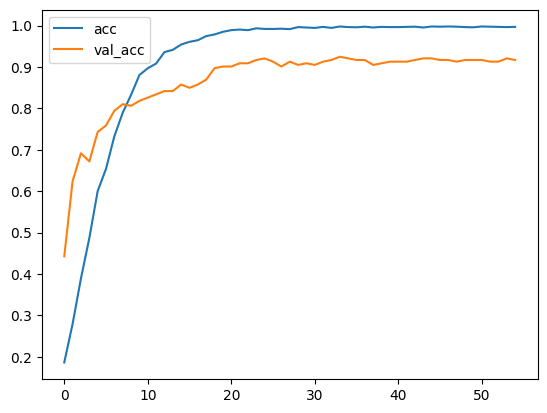

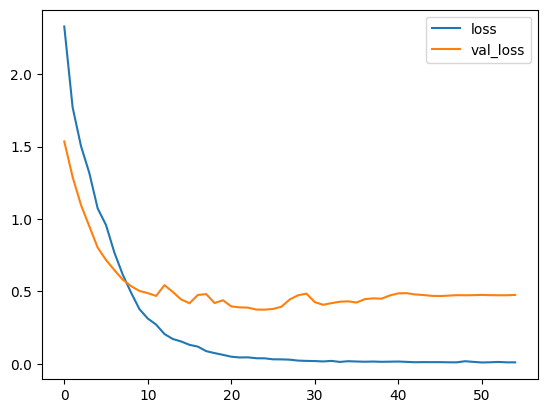

Entrenando modelo con semilla: 7


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       262,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,349,574 (28.04 MB)

 Trainable params: 7,265,926 (27.72 MB)

 Non-trainable params: 83,648 (326.75 KB)

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 288s 9s/step - loss: 2.1510 - sparse_categorical_accuracy: 0.2177 - val_loss: 1.4188 - val_sparse_categorical_accuracy: 0.4190 - learning_rate: 1.0000e-04
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 386ms/step - loss: 1.6357 - sparse_categorical_accuracy: 0.3459 - val_loss: 1.2026 - val_sparse_categorical_accuracy: 0.5850 - learning_rate: 1.0000e-04
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 379ms/step - loss: 1.3744 - sparse_categorical_accuracy: 0.4478 - val_loss: 0.9959 - val_sparse_categorical_accuracy: 0.6759 - learning_rate: 1.0000e-04
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 393ms/step - loss: 1.1580 - sparse_categorical_accuracy: 0.5477 - val_loss: 0.8474 - val_sparse_categorical_accuracy: 0.7194 - learning_rate: 1.0000e-04
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 389ms/step - loss: 0.9776 - sparse_categorical_accuracy: 0.6319 - val_loss: 0.7188 - val_sparse_categorical_accuracy: 0.7510 - learning_rate: 1.0000e-04
Epoch 6/150
16/16 ━━━━━━━

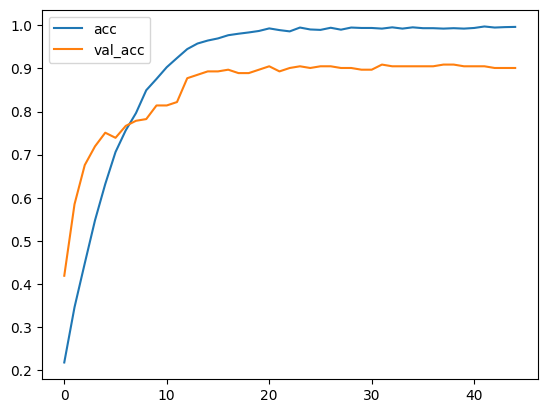

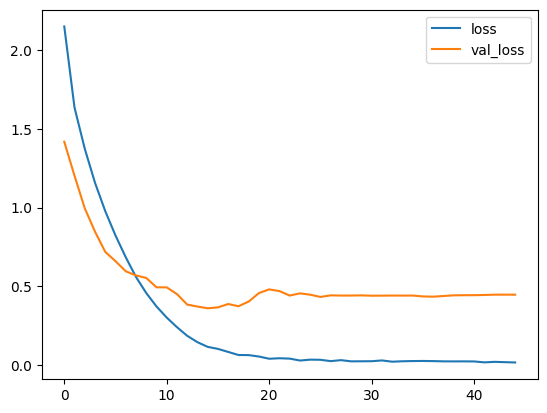

Entrenando modelo con semilla: 99


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       262,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,349,574 (28.04 MB)

 Trainable params: 7,265,926 (27.72 MB)

 Non-trainable params: 83,648 (326.75 KB)

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 290s 9s/step - loss: 2.1975 - sparse_categorical_accuracy: 0.2291 - val_loss: 1.4877 - val_sparse_categorical_accuracy: 0.4506 - learning_rate: 1.0000e-04
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 391ms/step - loss: 1.6998 - sparse_categorical_accuracy: 0.3469 - val_loss: 1.2146 - val_sparse_categorical_accuracy: 0.5771 - learning_rate: 1.0000e-04
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 383ms/step - loss: 1.4351 - sparse_categorical_accuracy: 0.4330 - val_loss: 1.0350 - val_sparse_categorical_accuracy: 0.6324 - learning_rate: 1.0000e-04
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 393ms/step - loss: 1.2098 - sparse_categorical_accuracy: 0.5413 - val_loss: 0.8814 - val_sparse_categorical_accuracy: 0.6680 - learning_rate: 1.0000e-04
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 385ms/step - loss: 1.0477 - sparse_categorical_accuracy: 0.6126 - val_loss: 0.7520 - val_sparse_categorical_accuracy: 0.7273 - learning_rate: 1.0000e-04
Epoch 6/150
16/16 ━━━━━━

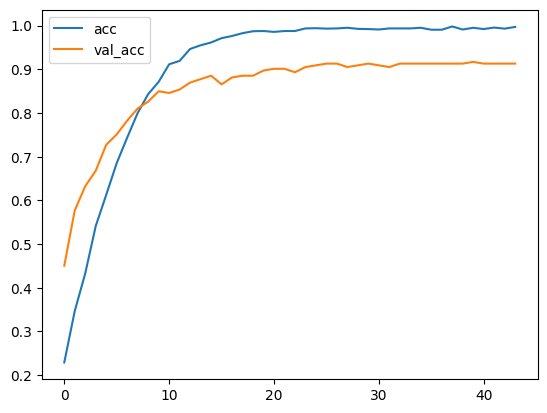

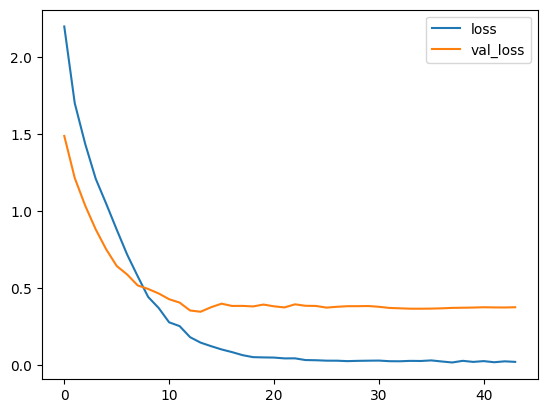

Archivos guardados en: /content/drive/MyDrive/garbage-classification-reports/semillas/modelo9


In [23]:
from pathlib import Path
import json

semillas = [42, 123, 7, 99]
resultados = {}
histories = {}

# En Colab conviene guardar en Drive para no perder resultados al cerrar la sesion.
# Si no montas Drive, se guardara en la carpeta local del runtime.
if "google.colab" in str(get_ipython()):
    base_dir = Path("/content/drive/MyDrive/garbage-classification-reports")
else:
    base_dir = Path("reports")

seed_dir = base_dir / "semillas" / "modelo9"
for subdir in ["acc", "loss", "conf_matrix", "histories", "comparativas"]:
    (seed_dir / subdir).mkdir(parents=True, exist_ok=True)

for i in semillas:
    print(f"Entrenando modelo con semilla: {i}")
    aplicar_semilla(i)

   #Defunimos arquitectura y compilamos el modelo
    model = estructura_modelo(input_shape=(128, 128, 3), num_classes=len(le.classes_))#,use_augmentation=True)
    model = compilar(model,learning_rate=1e-4)

    #Definimos callbacks
    ReduceLROnPlateau=tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    )
    EarlyStopping=tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=30,
            restore_best_weights=True,
            verbose=1
        )


    #Ponemos a entrenar el modelo
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=150,
        batch_size=128,
        callbacks=[ReduceLROnPlateau,EarlyStopping]
    )

    train = model.evaluate(x_train, y_train, verbose=0,steps=100)
    val = model.evaluate(x_val, y_val, verbose=0,steps=100)
    test = model.evaluate(x_test, y_test, verbose=0,steps=100)
    resultados[i] = {'train': train, 'val': val, 'test': test}

    histories[i] = history.history
    pd.DataFrame(history.history).to_csv(seed_dir / "histories" / f"history_seed_{i}.csv", index=False)

    graf_acc(history, save_path=seed_dir / "acc" / f"acc_seed_{i}.png")
    graf_pedida(history, save_path=seed_dir / "loss" / f"loss_seed_{i}.png")

    #y_pred = np.argmax(model.predict(x_test), axis=1)


    #print(f"Classification Report {i} - test:")
    #print(classification_report(y_test, y_pred, target_names=le.classes_))

with open(seed_dir / "histories" / "histories_modelo9.json", "w", encoding="utf-8") as f:
    json.dump(histories, f)

print(f"Archivos guardados en: {seed_dir}")

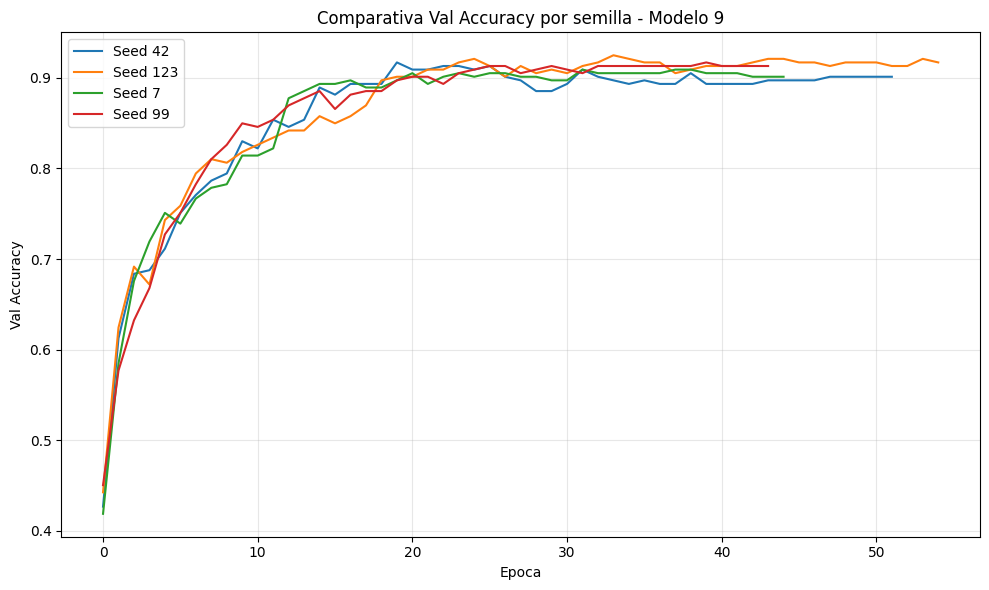

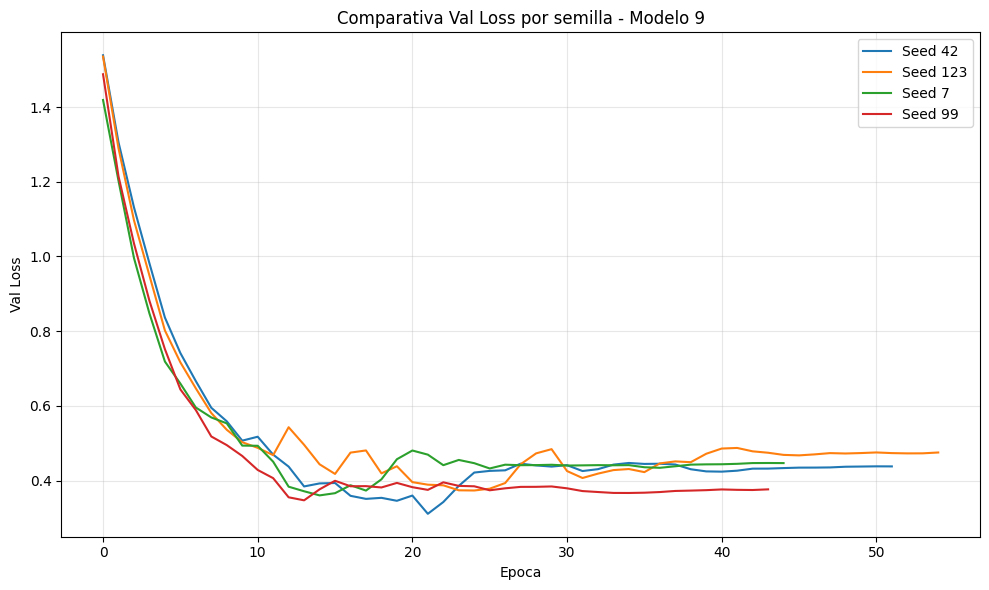

In [24]:
# Comparativa: 4 curvas (una por semilla) en una sola grafica para val_accuracy
plt.figure(figsize=(10, 6))
for seed, h in histories.items():
    plt.plot(h["val_sparse_categorical_accuracy"], label=f"Seed {seed}")

plt.title("Comparativa Val Accuracy por semilla - Modelo 9")
plt.xlabel("Epoca")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(seed_dir / "comparativas" / "comparativa_val_acc_semillas.png", dpi=150)
plt.show()
plt.close()

# Comparativa adicional para val_loss
plt.figure(figsize=(10, 6))
for seed, h in histories.items():
    plt.plot(h["val_loss"], label=f"Seed {seed}")

plt.title("Comparativa Val Loss por semilla - Modelo 9")
plt.xlabel("Epoca")
plt.ylabel("Val Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(seed_dir / "comparativas" / "comparativa_val_loss_semillas.png", dpi=150)
plt.show()
plt.close()

In [25]:
# Extrae solo el accuracy (índice 1) de cada lista
resultados_clean = {
    seed: {split: valores[1] for split, valores in metricas.items()}
    for seed, metricas in resultados.items()
}

df_resultados = pd.DataFrame(resultados_clean).T
df_resultados.index.name = 'Seed'
df_resultados.columns = ['Train Accuracy', 'Val Accuracy', 'Test Accuracy']
df_resultados.loc['Media'] = df_resultados.mean()

print(df_resultados.round(4))

       Train Accuracy  Val Accuracy  Test Accuracy
Seed                                              
42             0.9990        0.9091         0.8933
123            0.9990        0.9209         0.8854
7              0.9960        0.8933         0.8577
99             0.9941        0.8775         0.8538
Media          0.9970        0.9002         0.8725


In [26]:
!pip install tabulate

In [27]:
print(df_resultados.round(4).to_markdown())

| Seed   |   Train Accuracy |   Val Accuracy |   Test Accuracy |
|:-------|-----------------:|---------------:|----------------:|
| 42     |           0.999  |         0.9091 |          0.8933 |
| 123    |           0.999  |         0.9209 |          0.8854 |
| 7      |           0.996  |         0.8933 |          0.8577 |
| 99     |           0.9941 |         0.8775 |          0.8538 |
| Media  |           0.997  |         0.9002 |          0.8725 |
